In [106]:
# Import

import math
import joblib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [107]:
# Set random seed for reproducibility

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [108]:
# Select available device

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [109]:
# Load dataset

file_path = Path("../data/household_power_consumption.txt")

df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

print("Original shape:", df.shape)

df.head()

Original shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [110]:
# Inspect dataset

df.info()

# Display column names

print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 176.0 MB
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


In [111]:
# Combine Date and Time into one timestamp column

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

print("Invalid timestamps:", df["Datetime"].isna().sum())

Invalid timestamps: 0


In [112]:
# Organize time-series data

df = df.drop(columns=["Date", "Time"])
df = df.dropna(subset=["Datetime"])
df = df.sort_values("Datetime")
df = df.set_index("Datetime")

df = df.apply(pd.to_numeric, errors="coerce")

print("Updated shape:", df.shape)
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Duplicate timestamps:", df.index.duplicated().sum())

df.head()

Updated shape: (2075259, 7)
Start date: 2006-12-16 17:24:00
End date: 2010-11-26 21:02:00
Duplicate timestamps: 0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [113]:
# Remove duplicate timestamps

df = df[~df.index.duplicated(keep="first")]

print("Duplicate timestamps:", df.index.duplicated().sum())

Duplicate timestamps: 0


In [114]:
# Examine missing values

missing_counts = df.isna().sum()
missing_percentages = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percentages
})

missing_summary

# Count rows with missing values

rows_with_missing = df.isna().any(axis=1).sum()
missing_row_percentage = (rows_with_missing / len(df)) * 100

print("Rows with missing values:", rows_with_missing)
print(f"Percentage of rows with missing values: {missing_row_percentage:.2f}%")

Rows with missing values: 25979
Percentage of rows with missing values: 1.25%


In [115]:
# Resample data into hourly averages

hourly_df = df.resample("h").mean()

print("Hourly shape:", hourly_df.shape)

hourly_df.head()

Hourly shape: (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [116]:
# Fill missing values using time-based interpolation

hourly_df = hourly_df.interpolate(
    method="time",
    limit_direction="both"
)

print("Remaining missing values:", hourly_df.isna().sum().sum())

Remaining missing values: 0


In [ ]:
# Save hourly-resampled data to CSV

hourly_csv_path = Path("../data/household_power_consumption_hourly.csv")
hourly_df.to_csv(hourly_csv_path)

print("Hourly data saved to:", hourly_csv_path)

In [117]:
# Inspect hourly dataset

hourly_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34589 non-null  float64
 1   Global_reactive_power  34589 non-null  float64
 2   Voltage                34589 non-null  float64
 3   Global_intensity       34589 non-null  float64
 4   Sub_metering_1         34589 non-null  float64
 5   Sub_metering_2         34589 non-null  float64
 6   Sub_metering_3         34589 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


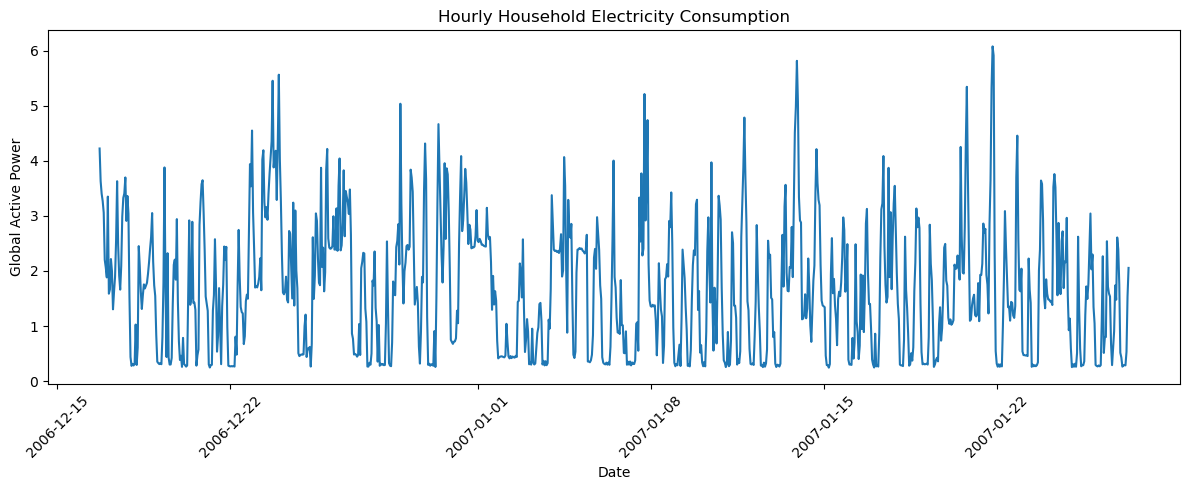

In [118]:
# Plot hourly electricity consumption

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_df.index[:1000],
    hourly_df["Global_active_power"][:1000]
)

plt.title("Hourly Household Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

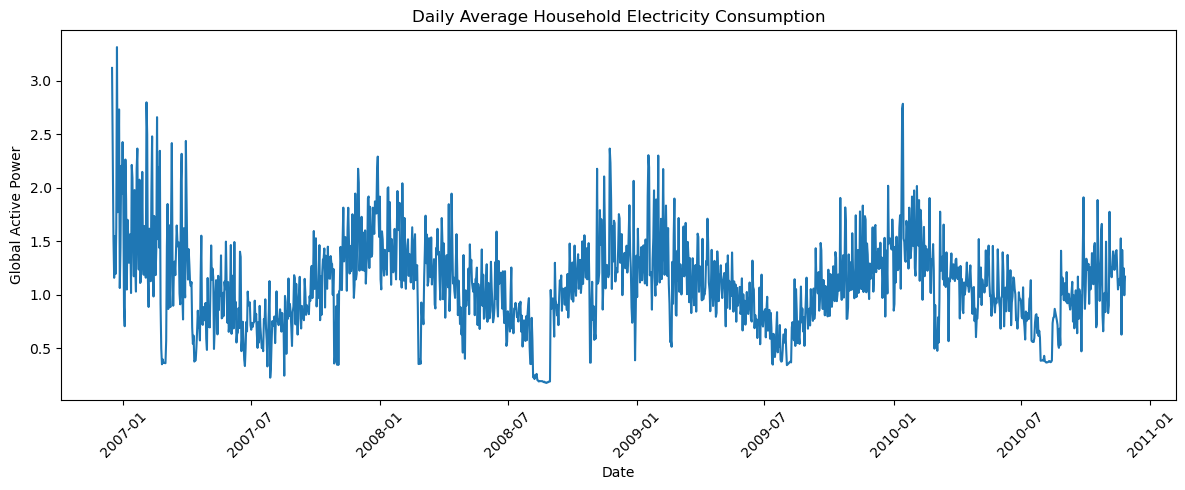

In [119]:
# Plot daily average electricity consumption

daily_power = hourly_df["Global_active_power"].resample("D").mean()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_power.index,
    daily_power
)

plt.title("Daily Average Household Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [120]:
# Select input features and target

feature_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

target_column = "Global_active_power"

model_df = hourly_df[feature_columns].copy()

print("Model dataset shape:", model_df.shape)

model_df.head()

Model dataset shape: (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [121]:
# Split dataset chronologically

train_end = int(len(model_df) * 0.70)
validation_end = int(len(model_df) * 0.85)

train_df = model_df.iloc[:train_end]
validation_df = model_df.iloc[train_end:validation_end]
test_df = model_df.iloc[validation_end:]

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (24212, 7)
Validation shape: (5188, 7)
Testing shape: (5189, 7)


In [122]:
# Scale features and target

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features = feature_scaler.fit_transform(
    train_df[feature_columns]
)

validation_features = feature_scaler.transform(
    validation_df[feature_columns]
)

test_features = feature_scaler.transform(
    test_df[feature_columns]
)

train_targets = target_scaler.fit_transform(
    train_df[[target_column]]
).flatten()

validation_targets = target_scaler.transform(
    validation_df[[target_column]]
).flatten()

test_targets = target_scaler.transform(
    test_df[[target_column]]
).flatten()

print("Training features shape:", train_features.shape)
print("Training targets shape:", train_targets.shape)

Training features shape: (24212, 7)
Training targets shape: (24212,)


In [123]:
# Create time-series sequences

class ElectricityDataset(Dataset):

    def __init__(self, features, targets, sequence_length):
        self.features = torch.tensor(
            features,
            dtype=torch.float32
        )

        self.targets = torch.tensor(
            targets,
            dtype=torch.float32
        )

        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, index):
        x = self.features[
            index:index + self.sequence_length
        ]

        y = self.targets[
            index + self.sequence_length
        ]

        return x, y

In [124]:
# Create datasets

sequence_length = 24

train_dataset = ElectricityDataset(
    train_features,
    train_targets,
    sequence_length
)

validation_dataset = ElectricityDataset(
    validation_features,
    validation_targets,
    sequence_length
)

test_dataset = ElectricityDataset(
    test_features,
    test_targets,
    sequence_length
)

print("Training sequences:", len(train_dataset))
print("Validation sequences:", len(validation_dataset))
print("Testing sequences:", len(test_dataset))

Training sequences: 24188
Validation sequences: 5164
Testing sequences: 5165


In [125]:
# Create data loaders

batch_size = 64

generator = torch.Generator()
generator.manual_seed(seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    generator=generator
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

x_batch, y_batch = next(iter(train_loader))

print("Input batch shape:", x_batch.shape)
print("Target batch shape:", y_batch.shape)

Input batch shape: torch.Size([64, 24, 7])
Target batch shape: torch.Size([64])


In [126]:
# Define positional encoding

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_length=5000):
        super().__init__()

        position = torch.arange(
            max_length,
            dtype=torch.float32
        ).unsqueeze(1)

        division_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32
            ) * (-math.log(10000.0) / d_model)
        )

        positional_encoding = torch.zeros(
            max_length,
            d_model
        )

        positional_encoding[:, 0::2] = torch.sin(
            position * division_term
        )

        positional_encoding[:, 1::2] = torch.cos(
            position * division_term
        )

        positional_encoding = positional_encoding.unsqueeze(0)

        self.register_buffer(
            "positional_encoding",
            positional_encoding
        )

    def forward(self, x):
        sequence_length = x.size(1)

        return (
            x
            + self.positional_encoding[:, :sequence_length]
        )

In [127]:
# Define transformer model

class ElectricityTransformer(nn.Module):

    def __init__(
        self,
        input_size,
        d_model,
        num_heads,
        num_layers,
        dim_feedforward,
        dropout
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            input_size,
            d_model
        )

        self.positional_encoding = PositionalEncoding(
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.output_layer = nn.Linear(
            d_model,
            1
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)

        x = x[:, -1, :]
        x = self.output_layer(x)

        return x.squeeze(-1)

In [128]:
# Initialize model

input_size = len(feature_columns)
d_model = 64
num_heads = 4
num_layers = 2
dim_feedforward = 128
dropout = 0.1

model = ElectricityTransformer(
    input_size=input_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout
).to(device)

print(model)

ElectricityTransformer(
  (input_projection): Linear(in_features=7, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [129]:
# Define loss function and optimizer

learning_rate = 0.001

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

In [130]:
# Define training function

def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0

    for features, targets in data_loader:
        features = features.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        predictions = model(features)

        loss = criterion(
            predictions,
            targets
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(data_loader)

    return average_loss

In [131]:
# Define validation function

def evaluate_loss(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0

    with torch.no_grad():

        for features, targets in data_loader:
            features = features.to(device)
            targets = targets.to(device)

            predictions = model(features)

            loss = criterion(
                predictions,
                targets
            )

            total_loss += loss.item()

    average_loss = total_loss / len(data_loader)

    return average_loss

In [132]:
# Train model

epochs = 20

train_losses = []
validation_losses = []

best_validation_loss = float("inf")

model_path = Path("../models/best_transformer_model.pt")

for epoch in range(epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    validation_loss = evaluate_loss(
        model,
        validation_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss

        torch.save(
            model.state_dict(),
            model_path
        )

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Training Loss: {train_loss:.4f} "
        f"- Validation Loss: {validation_loss:.4f}"
    )

Epoch 1/20 - Training Loss: 0.4234 - Validation Loss: 0.3962
Epoch 2/20 - Training Loss: 0.3785 - Validation Loss: 0.3733
Epoch 3/20 - Training Loss: 0.3665 - Validation Loss: 0.3578
Epoch 4/20 - Training Loss: 0.3546 - Validation Loss: 0.3599
Epoch 5/20 - Training Loss: 0.3517 - Validation Loss: 0.3459
Epoch 6/20 - Training Loss: 0.3454 - Validation Loss: 0.3435
Epoch 7/20 - Training Loss: 0.3426 - Validation Loss: 0.3657
Epoch 8/20 - Training Loss: 0.3398 - Validation Loss: 0.3684
Epoch 9/20 - Training Loss: 0.3356 - Validation Loss: 0.3404
Epoch 10/20 - Training Loss: 0.3348 - Validation Loss: 0.3478
Epoch 11/20 - Training Loss: 0.3271 - Validation Loss: 0.3485
Epoch 12/20 - Training Loss: 0.3252 - Validation Loss: 0.3567
Epoch 13/20 - Training Loss: 0.3239 - Validation Loss: 0.3560
Epoch 14/20 - Training Loss: 0.3193 - Validation Loss: 0.3578
Epoch 15/20 - Training Loss: 0.3185 - Validation Loss: 0.3572
Epoch 16/20 - Training Loss: 0.3165 - Validation Loss: 0.3671
Epoch 17/20 - Tra

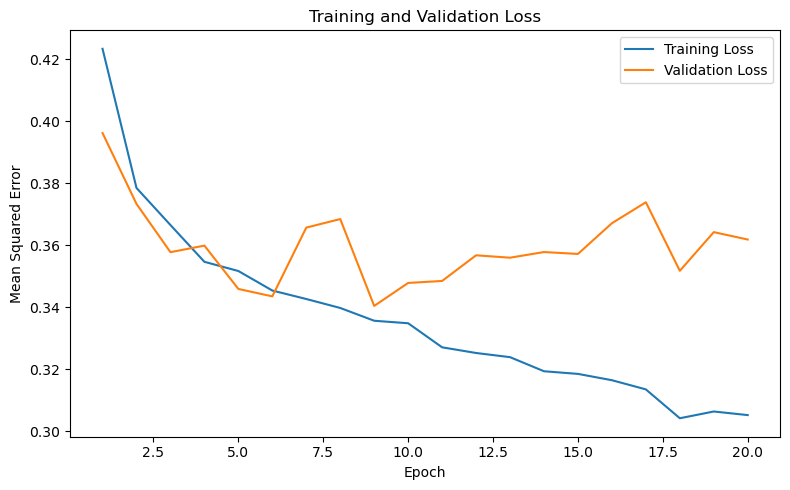

In [133]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, epochs + 1),
    validation_losses,
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.tight_layout()
plt.show()

In [134]:
# Load best model

model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

model.eval()

print("Best validation loss:", best_validation_loss)

Best validation loss: 0.34041909413573185


In [135]:
# Generate test predictions

test_predictions = []
test_actuals = []

with torch.no_grad():

    for features, targets in test_loader:
        features = features.to(device)

        predictions = model(features)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_actuals.extend(
            targets.numpy()
        )

test_predictions = np.array(
    test_predictions
).reshape(-1, 1)

test_actuals = np.array(
    test_actuals
).reshape(-1, 1)

In [136]:
# Convert predictions to original scale

test_predictions = target_scaler.inverse_transform(
    test_predictions
).flatten()

test_actuals = target_scaler.inverse_transform(
    test_actuals
).flatten()

print("Number of predictions:", len(test_predictions))

Number of predictions: 5165


In [137]:
# Evaluate model performance

mae = mean_absolute_error(
    test_actuals,
    test_predictions
)

mse = mean_squared_error(
    test_actuals,
    test_predictions
)

rmse = np.sqrt(mse)

print(f"Test MAE: {mae:.4f}")
print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.3208
Test MSE: 0.2156
Test RMSE: 0.4643


In [ ]:
# Baseline: persistence (naive) model - predicts the next value equals the previous hour's actual value

persistence_predictions = test_df[target_column].iloc[
    sequence_length - 1 : sequence_length - 1 + len(test_actuals)
].to_numpy()

baseline_mae = mean_absolute_error(test_actuals, persistence_predictions)
baseline_mse = mean_squared_error(test_actuals, persistence_predictions)
baseline_rmse = np.sqrt(baseline_mse)

print(f"Persistence Baseline MAE: {baseline_mae:.4f}")
print(f"Persistence Baseline MSE: {baseline_mse:.4f}")
print(f"Persistence Baseline RMSE: {baseline_rmse:.4f}")

improvement_mae = (1 - mae / baseline_mae) * 100
print(f"\nTransformer improvement over baseline (MAE): {improvement_mae:.2f}%")

Persistence Baseline MAE: 0.3723
Persistence Baseline MSE: 0.3300
Persistence Baseline RMSE: 0.5745

Transformer improvement over baseline (MAE): 13.83%


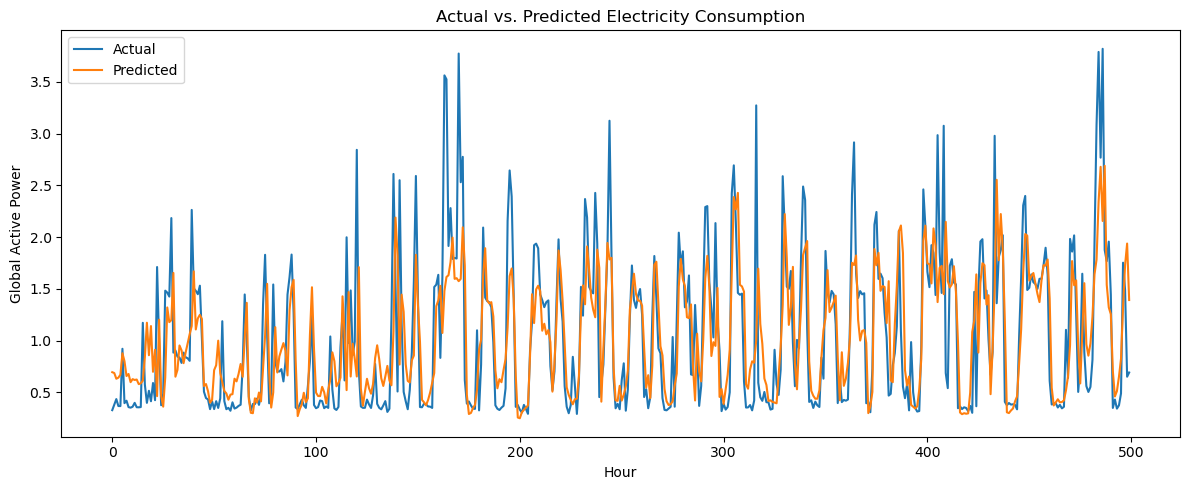

In [138]:
# Plot actual and predicted electricity consumption

plot_length = 500

plt.figure(figsize=(12, 5))

plt.plot(
    test_actuals[:plot_length],
    label="Actual"
)

plt.plot(
    test_predictions[:plot_length],
    label="Predicted"
)

plt.title("Actual vs. Predicted Electricity Consumption")
plt.xlabel("Hour")
plt.ylabel("Global Active Power")
plt.legend()
plt.tight_layout()
plt.show()

In [139]:
# Save model results

results_df = pd.DataFrame({
    "Actual": test_actuals,
    "Predicted": test_predictions
})

results_path = Path("../models/test_predictions.csv")

results_df.to_csv(
    results_path,
    index=False
)

print("Results saved to:", results_path)

Results saved to: ../models/test_predictions.csv


In [140]:
# Save fitted scalers

feature_scaler_path = Path(
    "../models/feature_scaler.pkl"
)

target_scaler_path = Path(
    "../models/target_scaler.pkl"
)

joblib.dump(
    feature_scaler,
    feature_scaler_path
)

joblib.dump(
    target_scaler,
    target_scaler_path
)

print("Feature scaler saved to:", feature_scaler_path)
print("Target scaler saved to:", target_scaler_path)

Feature scaler saved to: ../models/feature_scaler.pkl
Target scaler saved to: ../models/target_scaler.pkl
